# Script to extract and visualize ICES data at CodeBlue station points
- Input file format: station.csv + ./ICESData_for_validation/{var}_{year}.parquet
- Output file format: ICESdata_{station}.parquet
  
- ICES data have been downloaded via: https://data.ices.dk/view-map. Dataset: Ocean hydrochemistry/Bottle and Low Resolution CTD Data.  
- This script have already been processed for the period 1960-2025 and variables: Oxy, NOx, NH4, PO4, SiO, Chl, Temp, Sal, SPM, pH, TA.
####  Structure:  
1. Reads the target station list from a CSV file.
2. Visualizes the stations by station type.
3. Reads ICES Parquet files for the selected variables and years.
4. Matches observations to the nearest target station using a **distance tolerance in kilometres**.
5. Keeps all available depths and adds `station`, `lat`, and `lon` to the output.
6. Combines all variables and years into **one compressed Parquet file per station**.
7. Creates a summary file describing the data available at each station.

- Output .parquet files are available in **GoogleDrive/2025_CodeBlue_project/WP4/ICESData_for_stations**

Authors: Capet A. & Denis P.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1. User settings

Update the three paths below. The ICES input folder should contain files such as
`oxy_2020.parquet`, `temp_2020.parquet`, etc.


In [76]:

datadir = Path("/hpcperm/bel9956/codeblue/ICESData_for_validation/") #input directory with ICES parquet files
station_file = Path("stations.csv") #station table
outdir = Path("/hpcperm/bel9956/codeblue/ICESData_for_stations/") #output directory where output parquet files are written

variables = ['oxy', 'nox', 'nh4', 'po4', 'sio', 'chl', 'temp', 'sal', 'spm', 'ph', 'talk']
years = range(1960, 2025+1)

# Maximum distance between an ICES observation and a target station.
tolerance_km = 5.0 #km /!\ TO BE DISCUSSED

# Keep observations with quality flag <= MAX_QV
# MAX_QV = 1

## 2. Read the station list

The station CSV is assumed to contain exactly these columns:
`station`, `lat`, `lon`, `type`.


In [77]:
# ==============================================================================
# READ STATIONS
# ==============================================================================
stations = pd.read_csv(station_file)

stations = stations[["station", "lat", "lon", "type"]].copy()

stations["lat"] = pd.to_numeric(stations["lat"])
stations["lon"] = pd.to_numeric(stations["lon"])

stations = stations.dropna(subset=["station", "lat", "lon"])

print(f"Number of stations: {len(stations)}")
print("\nStations by type:")
display(stations["type"].value_counts())

display(stations.head())

Number of stations: 128

Stations by type:


type
HELCOM_optional    40
OSPAR_optional     32
WP6                26
HELCOM             20
OSPAR              10
Name: count, dtype: int64

,station,lat,lon,type
0,LUNG_O14,54.113330,14.116671,HELCOM
1,LLUR_225058,54.315000,11.550000,HELCOM
2,LLUR_225006,54.600000,10.450000,HELCOM
3,GdanskDeep,54.833333,19.316667,HELCOM
4,TF0113,54.925000,13.500000,HELCOM


## 3. Visualize the stations

The map uses different colors for HELCOM, OSPAR and WP6 stations, while optional stations are displayed separately.

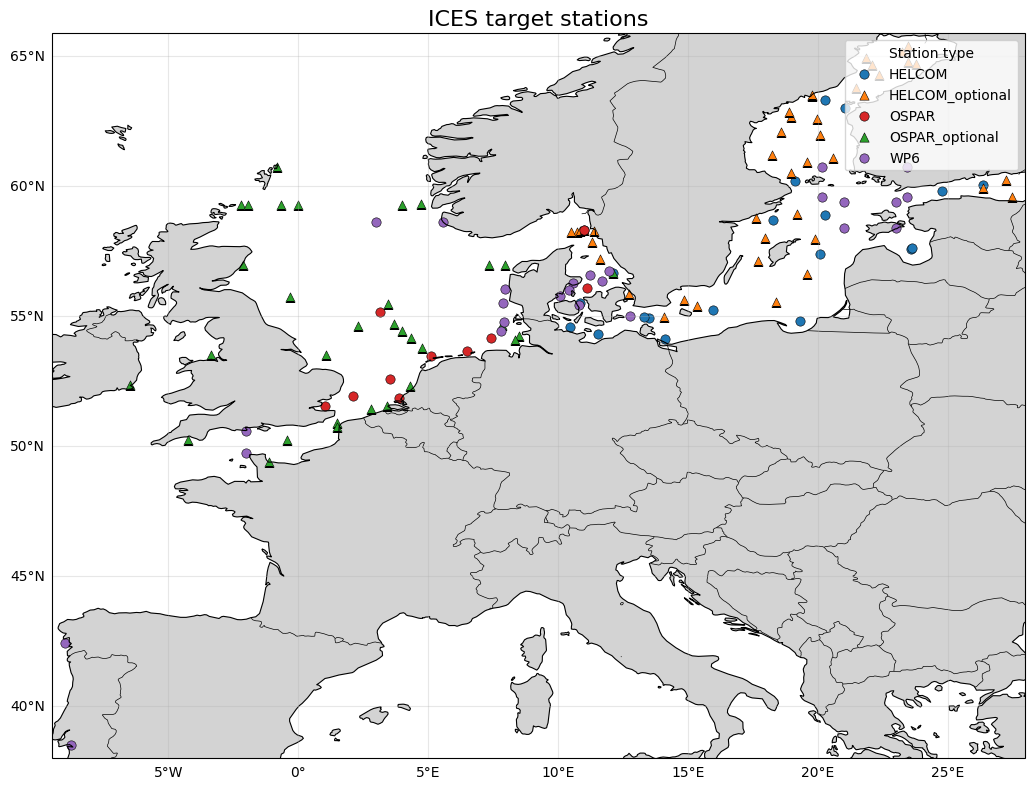

In [92]:
# ==============================================================================
# PLOT STATIONS
# ==============================================================================
def plot_stations(stations, figsize=(11, 8)):
    """Plot all target stations on a map."""

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    margin = 0.5

    ax.set_extent(
        [
            stations["lon"].min() - margin,
            stations["lon"].max() + margin,
            stations["lat"].min() - margin,
            stations["lat"].max() + margin,
        ],
        crs=ccrs.PlateCarree(),
    )

    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    markers = {
        "HELCOM": "o",
        "HELCOM_optional": "^",
        "OSPAR": "o",
        "OSPAR_optional": "^",
        "WP6": "o",
    }

    colors = {
        "HELCOM": "tab:blue",
        "HELCOM_optional": "tab:orange",
        "OSPAR": "tab:red",
        "OSPAR_optional": "tab:green",
        "WP6": "tab:purple",
    }

    for station_type, group in stations.groupby("type"):
        ax.scatter(
            group["lon"],
            group["lat"],
            marker=markers.get(station_type, "o"),
            color=colors.get(station_type, "gray"),
            s=45,
            edgecolor="black",
            linewidth=0.4,
            label=station_type,
            transform=ccrs.PlateCarree(),
        )

    gl = ax.gridlines(draw_labels=True, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    ax.legend(title="Station type", loc="upper right")
    ax.set_title("ICES target stations", fontsize=16)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_stations(stations)
plt.show()

## 4. Distance-based station matching

Because the ICES Parquet files do not contain the station ID, observations are associated with the **nearest target station** based on latitude/longitude.
The matching is performed using the haversine formula, so the tolerance is expressed directly in **kilometres**. 

In [68]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Return great-circle distance in kilometres.

    Inputs can be NumPy arrays. Broadcasting is supported.
    """

    earth_radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2.0) ** 2
    )

    return 2.0 * earth_radius_km * np.arcsin(np.sqrt(a))

In [69]:
# ==============================================================================
# MATCH OBSERVATIONS TO TARGET STATIONS
# ==============================================================================
def match_to_stations(data, stations, tolerance_km=tolerance_km):
    """Assign each observation to its nearest target station.

    Observations farther than tolerance_km are discarded.
    """

    data = data.copy()
    data = data.dropna(subset=["lat", "lon"])

    if data.empty:
        return data

    obs_lat = data["lat"].to_numpy()[:, None]
    obs_lon = data["lon"].to_numpy()[:, None]
            
    station_lat = stations["lat"].to_numpy()[None, :]
    station_lon = stations["lon"].to_numpy()[None, :]

    distances = haversine_distance_km(
        obs_lat,
        obs_lon,
        station_lat,
        station_lon,
    )

    nearest_idx = np.argmin(distances, axis=1)
    nearest_distance = distances[
        np.arange(len(data)),
        nearest_idx,
    ]

    keep = nearest_distance <= tolerance_km

    data = data.loc[keep].copy()

    if data.empty:
        return data

    nearest_idx = nearest_idx[keep]
    nearest_distance = nearest_distance[keep]

    matched_stations = stations.iloc[nearest_idx].reset_index(drop=True)

    data["station"] = matched_stations["station"].to_numpy()
    data["station_lat"] = matched_stations["lat"].to_numpy()
    data["station_lon"] = matched_stations["lon"].to_numpy()
    data["match_distance_km"] = nearest_distance

    return data


## 5. Read and process one variable/year
The original observation `lat`/`lon` are retained, together with the target station coordinates.

In [70]:
# ==============================================================================
# READ ONE VARIABLE / YEAR
# ==============================================================================

def read_variable_year(variable, year):
    """Read one ICES variable/year Parquet file."""

    filepath = datadir / f"{variable}_{year}.parquet"

    if not filepath.exists():
        return None

    df = pd.read_parquet(filepath)

    # Keep the columns needed for extraction.
    # The source files are expected to have this structure.
    columns = [
        "datetime",
        "lon",
        "lat",
        "depth",
        variable,
        f"{variable}_qv",
    ]

    df = df[columns].copy()

    # Quality control
    # df = df[df[f"{variable}_qv"] <= MAX_QV].copy()

    # Remove observations without a measurement
    df = df.dropna(subset=[variable])

    return df


def process_variable_year(variable, year):
    """Read one variable/year file and match it to target stations."""

    df = read_variable_year(variable, year)

    if df is None or df.empty:
        return None

    df = match_to_stations(
        df,
        stations,
        tolerance_km=tolerance_km,
    )

    if df.empty:
        return None

    # Keep original observation coordinates and depth.
    return df[
        [
            "station",
            "station_lat",
            "station_lon",
            "datetime",
            "lat",
            "lon",
            "depth",
            "match_distance_km",
            variable,
        ]
    ].copy()

## 6. Test the matching before processing everything

In [78]:
test_year = 2020
test_results = []

for variable in variables:
    df_test = process_variable_year(variable, test_year)

    if df_test is not None and not df_test.empty:
        test_results.append({
            "variable": variable,
            "observations": len(df_test),
            "stations": df_test["station"].nunique(),
            "mean_match_distance_km": df_test["match_distance_km"].mean(),
            "max_match_distance_km": df_test["match_distance_km"].max(),
        })

test_summary = pd.DataFrame(test_results)

display(test_summary)

,variable,observations,stations,mean_match_distance_km,max_match_distance_km
0,oxy,9648,72,1.303178,4.852697
1,nox,921,24,1.161815,4.666192
2,nh4,5073,73,1.505379,4.666192
3,po4,5367,80,1.481205,4.666192
4,sio,5344,80,1.472946,4.666192
5,chl,3374,74,1.455582,4.666192
6,temp,7739,73,1.183873,4.852697
7,sal,8134,77,1.187008,4.852697
8,ph,1250,40,1.335430,4.666192
9,talk,1320,20,1.435159,3.052439


### Optional: visualize the matched observations

This is useful for checking whether the chosen `tolerence_km` is sensible.

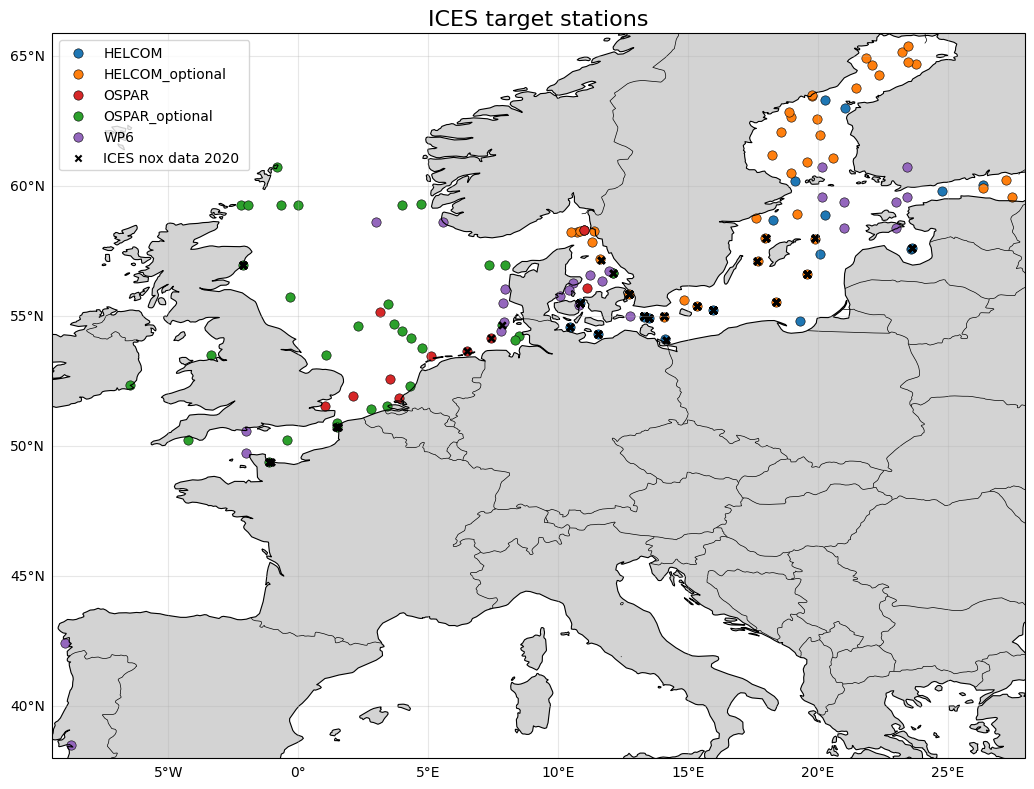

In [80]:
# ==============================================================================
# VISUALIZE MATCHED OBSERVATIONS
# ==============================================================================
test_variable = "nox"
test_df = process_variable_year(test_variable, test_year)

if test_df is not None and not test_df.empty:
    fig, ax = plot_stations(stations)

    ax.scatter(
        test_df["lon"],
        test_df["lat"],
        s=20,
        color="black",
        marker='x',
        transform=ccrs.PlateCarree(),
        label=f"ICES {test_variable} data {test_year} ",
    )

    ax.legend()
    plt.show()

## 7. Process all years and variables

The output is accumulated in memory by station. For each station, all variables and years are then combined into a single Parquet file.

The output is therefore:
```text
ICES_station_data/
├── STATION_1.parquet
├── STATION_2.parquet
├── ...
└── station_summary.csv
```

In [82]:
# ==============================================================================
# PROCESS ALL YEARS / VARIABLES
# ==============================================================================
station_data = {
    station: []
    for station in stations["station"]
}

processing_summary = []

for year in years:

    print("=" * 70)
    print(f"Processing year: {year}")
    print("=" * 70)
    year_has_file = False

    for variable in variables:

        filepath = datadir / f"{variable}_{year}.parquet"

        if not filepath.exists():
            print(f"  {variable}: file not found")
            continue
        year_has_file = True

        df = process_variable_year(variable, year)

        if df is None or df.empty:
            print(f"  {variable}: no matching observations")
            continue

        for station, group in df.groupby("station"):
            station_data[station].append(
                group.drop(columns="station")
            )

        processing_summary.append({
            "year": year,
            "variable": variable,
            "observations": len(df),
            "stations": df["station"].nunique(),
        })

        print(f"  {variable}: {len(df):,} observations, "f"{df['station'].nunique()} stations")

processing_summary = pd.DataFrame(processing_summary)

Processing year: 1960
  oxy: 657 observations, 16 stations
  nox: file not found
  nh4: file not found
  po4: 458 observations, 13 stations
  sio: 85 observations, 6 stations
  chl: no matching observations
  temp: 1,749 observations, 35 stations
  sal: 1,620 observations, 35 stations
  spm: file not found
  ph: 214 observations, 10 stations
  talk: 84 observations, 4 stations
Processing year: 1961
  oxy: 481 observations, 21 stations
  nox: file not found
  nh4: file not found
  po4: 71 observations, 6 stations
  sio: 75 observations, 6 stations
  chl: 4 observations, 1 stations
  temp: 1,634 observations, 39 stations
  sal: 1,470 observations, 39 stations
  spm: file not found
  ph: 134 observations, 8 stations
  talk: 29 observations, 2 stations
Processing year: 1962
  oxy: 1,035 observations, 22 stations
  nox: file not found
  nh4: 1 observations, 1 stations
  po4: 508 observations, 9 stations
  sio: 164 observations, 7 stations
  chl: file not found
  temp: 2,368 observations, 32

## 8. Combine and save one Parquet file per station

In [83]:
# ==============================================================================
# COMBINE AND SAVE STATION FILES
# ==============================================================================
summary = []

for station, data_list in station_data.items():

    if not data_list:
        summary.append({
            "station": station,
            "n_observations": 0,
            "n_years": 0,
            "variables": "",
        })
        continue

    df_station = pd.concat(
        data_list,
        ignore_index=True,
    )

    df_station = df_station.sort_values(
        ["datetime", "depth"]
    )

    # Remove exact duplicate rows while preserving different depths.
    df_station = df_station.drop_duplicates()

    # Save as compressed Parquet.
    output_file = outdir / f"{station}.parquet"

    df_station.to_parquet(
        output_file,
        engine="pyarrow",
        compression="zstd",
        index=False,
    )

    variables_available = [
        variable
        for variable in variables
        if variable in df_station.columns
        and df_station[variable].notna().any()
    ]

    summary.append({
        "station": station,
        "n_observations": len(df_station),
        "n_years": df_station["datetime"].dt.year.nunique(),
        "variables": ", ".join(variables_available),
    })

    print( f"{station}: {len(df_station):,} observations")

LUNG_O14: 5,997 observations
LLUR_225058: 22,861 observations
LLUR_225006: 14,451 observations
GdanskDeep: 55,622 observations
TF0113: 37,558 observations
BY1: 50,618 observations
BY2: 54,612 observations
BY5_Bornholm: 165,804 observations
BY4: 57,110 observations
GreatBelt: 37,268 observations
BCS_III_10: 72,021 observations
HANOBUKTEN: 30,193 observations
LANDSKRONA_W: 75,731 observations
BY10: 62,849 observations
ANHOLT: 208 observations
BY38: 62,801 observations
FLADEN: 53,446 observations
BY15: 1,199 observations
GulfofRiga_1: 15,682 observations
P2: 30,753 observations
BY20: 92,203 observations
BY32: 66,295 observations
A16: 18,132 observations
A17: 33,748 observations
A15: 24,519 observations
SLAGGO: 42,207 observations
A13: 31,812 observations
BY31_LandsortDeep: 102 observations
B1: 38,866 observations
BY29_NBP: 55,721 observations
HUVUDSKAR: 809 observations
N12: 5,362 observations
LL07_GoF: 36,322 observations
F1: 3,991 observations
LL3A_GoF: 12,310 observations
F64_Aland_sea

## 9. Save summaries

In [86]:
# ==============================================================================
# SAVE SUMMARIES
# ==============================================================================
station_summary = pd.DataFrame(summary)

station_summary.to_csv(
    outdir / "station_summary.csv",
    index=False,
            )

if not processing_summary.empty:
    processing_summary.to_csv(
        outdir / "processing_summary.csv",
        index=False,
    )

display(station_summary)

print(f"\nOutput directory: {outdir}")

,station,n_observations,n_years,variables
0,LUNG_O14,5997,37,"oxy, nox, nh4, po4, sio, chl, temp, sal, ph"
1,LLUR_225058,22861,43,"oxy, nox, nh4, po4, sio, chl, temp, sal, ph, talk"
2,LLUR_225006,14451,47,"oxy, nox, nh4, po4, sio, chl, temp, sal, ph, talk"
3,GdanskDeep,55622,58,"oxy, nox, nh4, po4, sio, chl, temp, sal, ph, talk"
4,TF0113,37558,41,"oxy, nox, nh4, po4, sio, chl, temp, sal"
...,...,...,...,...
121,Archipelago_CornerA4,369,6,"oxy, po4, sio, chl, temp, sal"
122,Archipelago_CornerB1,0,0,
123,Archipelago_CornerB2,1240,9,"oxy, nh4, po4, sio, chl, temp, sal, ph, talk"
124,Archipelago_CornerB3,18,1,"temp, sal"



Output directory: /hpcperm/bel9956/codeblue/ICESData_for_stations


## 10. Example: load one station and make a time series

The station Parquet files contain all available variables and depths. This makes them convenient for subsequent time-series analysis.

In [93]:
# ==============================================================================
# EXAMPLE TIME SERIES
# ==============================================================================
station_name = stations.iloc[0]["station"]
variable = "chl"

station_file = outdir / f"{station_name}.parquet"

df_station = pd.read_parquet(station_file)

print(f"Station: {station_name}")
print(f"Rows: {len(df_station):,}")
print(f"Columns: {list(df_station.columns)}")

display(df_station.head())

Station: LUNG_O14
Rows: 5,997
Columns: ['station_lat', 'station_lon', 'datetime', 'lat', 'lon', 'depth', 'match_distance_km', 'oxy', 'temp', 'sal', 'po4', 'nh4', 'sio', 'chl', 'ph', 'nox']


,station_lat,station_lon,datetime,lat,lon,depth,match_distance_km,oxy,temp,sal,po4,nh4,sio,chl,ph,nox
0,54.11333,14.116671,1967-06-17 00:00:00+00:00,54.12,14.17,0.0,3.553995,6.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,54.11333,14.116671,1967-06-17 00:00:00+00:00,54.12,14.17,0.0,3.553995,NaN,14.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54.11333,14.116671,1967-06-17 00:00:00+00:00,54.12,14.17,0.0,3.553995,NaN,NaN,6.37,NaN,NaN,NaN,NaN,NaN,NaN
3,54.11333,14.116671,1983-06-24 14:09:00+00:00,54.13,14.18,1.0,4.524164,6.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54.11333,14.116671,1983-06-24 14:09:00+00:00,54.13,14.18,1.0,4.524164,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,NaN


/etc/ecmwf/ssd/ssd1/jupyterhub/bel9956-jupyterhub/tmpdirs/bel9956.31200448/ipykernel_3260077/1412806818.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Depth")


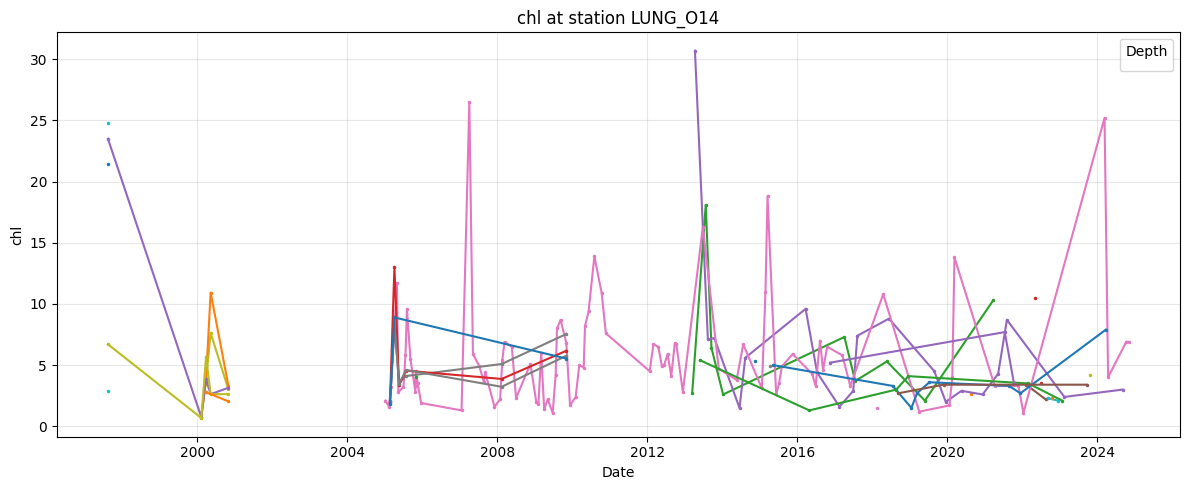

In [95]:
# Plot all available depths for one variable
fig, ax = plt.subplots(figsize=(12, 5))

for depth, group in df_station.dropna(subset=[variable]).groupby("depth"):
    group = group.sort_values("datetime")
    ax.plot(
        group["datetime"],
        group[variable],
        ".-",
        markersize=3,
        # label=f"{depth:g} m",
    )

ax.set_xlabel("Date")
ax.set_ylabel(variable)
ax.set_title(f"{variable} at station {station_name}")
ax.grid(alpha=0.3)
ax.legend(title="Depth")

plt.tight_layout()
plt.show()